In [29]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [27]:
def mean_squared_error(x, y):
    return np.mean(np.square(x - y))

# Task 1

In [8]:
t = np.linspace(0, 6 * np.pi, 300)
y = np.sin(t) + np.random.normal(0, 0.1, 300)

In [7]:
window_size = 10
forecast_horizon = 3

X = []
Y = []

for i in range(len(y) - window_size - forecast_horizon + 1):
    X.append(y[i:i+window_size])
    Y.append(y[i+window_size:i+window_size+forecast_horizon])
X = np.array(X)
X = X.reshape(X.shape[0], X.shape[1], 1)
Y = np.array(Y)
print(f"X shape: {X.shape}, Y shape: {Y.shape}")

X shape: (288, 10, 1), Y shape: (288, 3)


In [11]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
Y_train = Y[:train_size]
X_test = X[train_size:]
Y_test = Y[train_size:]

print(f"X_train : {X_train.shape}, Y_train : {Y_train.shape}\n X_test : {X_test.shape}, Y_test : {Y_test.shape}")

X_train : (230, 10, 1), Y_train : (230, 3)
 X_test : (58, 10, 1), Y_test : (58, 3)


# Task 2

In [24]:
early_stopping = EarlyStopping(
    patience=10,
    monitor='accuracy',
    restore_best_weights=True
)

In [31]:
model = Sequential([
    LSTM(64, input_shape=(10, 1), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(3)
])
model.compile(optimizer=Adam(), loss='mse', metrics=['accuracy'])
model.summary()

D:\ML_College\CV\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,075 (74.51 KB)

 Trainable params: 19,075 (74.51 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    X_train,
    Y_train,
    epochs=150,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.3348 - loss: 0.3498
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3565 - loss: 0.1205
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3478 - loss: 0.0813
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3522 - loss: 0.0693
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3565 - loss: 0.0632
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3696 - loss: 0.0546
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3783 - loss: 0.0451
Epoch 8/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3826 - loss: 0.0395
Epoch 9/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4130 - loss: 0.0261
Epoch 10/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4348 - loss: 0.0185
Epoch 11/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4348 - loss: 0.0182
Epoch 12/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

In [28]:
predictions = model.predict(X_test)

mse_step1 = mean_squared_error(Y_test[:, 0], predictions[:, 0])
mse_step2 = mean_squared_error(Y_test[:, 1], predictions[:, 1])
mse_step3 = mean_squared_error(Y_test[:, 2], predictions[:, 2])

print("\n===== LSTM Results =====")
print(f"Step 1 MSE: {mse_step1:.6f}")
print(f"Step 2 MSE: {mse_step2:.6f}")
print(f"Step 3 MSE: {mse_step3:.6f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step

===== LSTM Results =====
Step 1 MSE: 0.016022
Step 2 MSE: 0.016274
Step 3 MSE: 0.019328


# Task 3

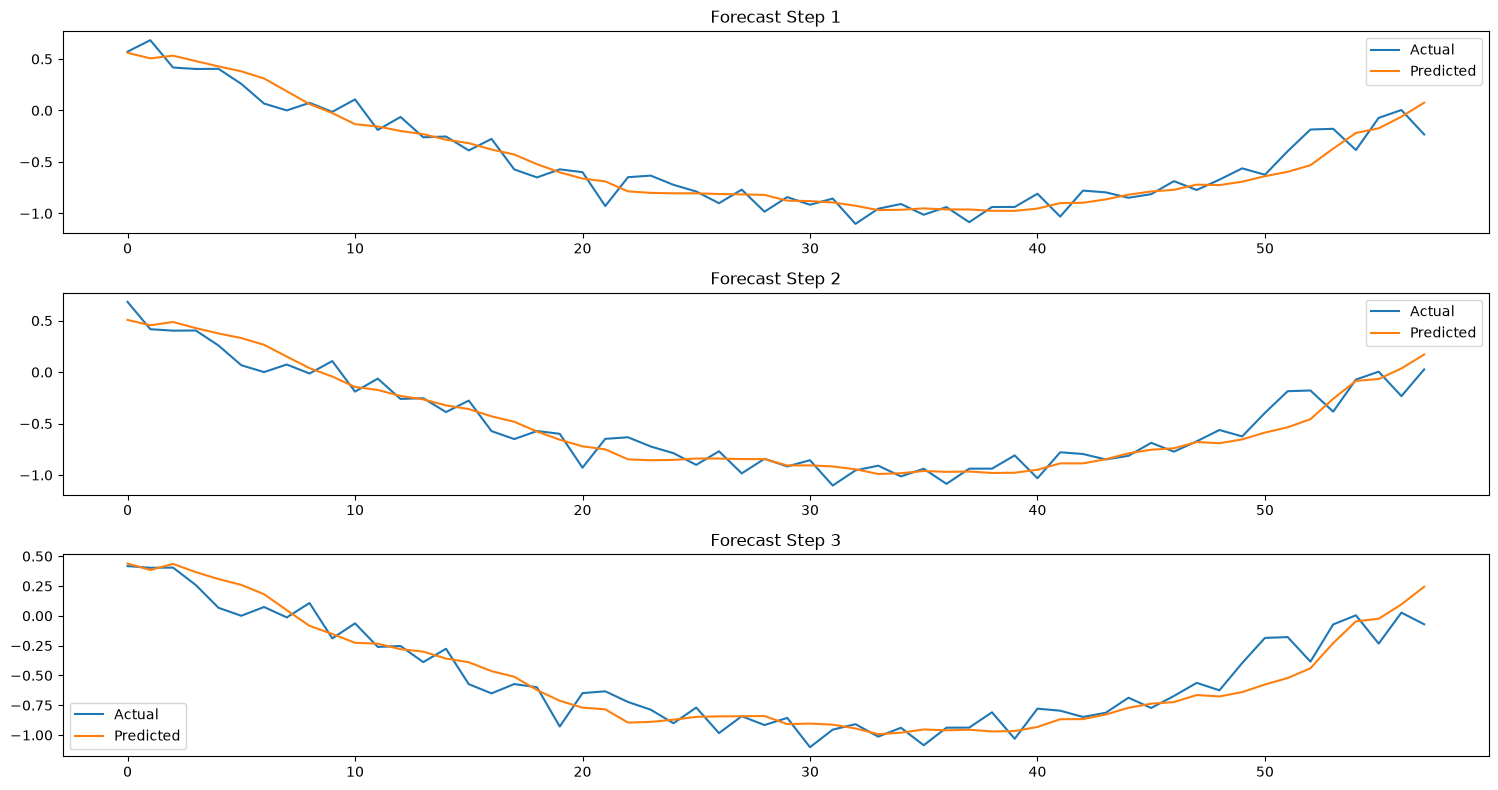

In [30]:

plt.figure(figsize=(15, 8))

# Step 1
plt.subplot(3,1,1)
plt.plot(Y_test[:,0], label='Actual')
plt.plot(predictions[:,0], label='Predicted')
plt.title('Forecast Step 1')
plt.legend()

# Step 2
plt.subplot(3,1,2)
plt.plot(Y_test[:,1], label='Actual')
plt.plot(predictions[:,1], label='Predicted')
plt.title('Forecast Step 2')
plt.legend()

# Step 3
plt.subplot(3,1,3)
plt.plot(Y_test[:,2], label='Actual')
plt.plot(predictions[:,2], label='Predicted')
plt.title('Forecast Step 3')
plt.legend()

plt.tight_layout()
plt.show()

# Task 4

In [36]:
deeper_model = Sequential([
    LSTM(128, input_shape=(10, 1), return_sequences=True),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(3)
])
deeper_model.compile(optimizer=Adam(), loss='mse')
deeper_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 10, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,147 (461.51 KB)

 Trainable params: 118,147 (461.51 KB)

 Non-trainable params: 0 (0.00 B)